# 85. The Uncapacitated Facility Location Problem
## Tier 1: The Pen & Paper Method (Mathematical CSP Formulation)

### Key assumptions
- Facilities have no capacity constraints (uncapacitated)
- Each customer must be assigned to exactly one facility
- A facility can only serve customers if it is opened
- Fixed costs are incurred for opening facilities
- Transportation costs are linear with distance/volume

### Approach (step-by-step)
1. **Formulate as Constraint Satisfaction Problem**
   - Define binary variables for facility opening decisions
   - Define binary variables for customer-facility assignments
   - Apply constraint propagation techniques

2. **Apply systematic domain reduction**
   - Use constraint propagation to reduce variable domains
   - Implement branch-and-bound search for optimal solution
   - Handle linking constraints between facility and assignment variables

3. **Extract and validate solution**
   - Ensure all customers are assigned
   - Verify facility opening consistency
   - Calculate total cost (fixed + transportation)

### What to look for in the results
- Which facilities are opened (binary decisions)
- Customer-to-facility assignment matrix
- Total cost breakdown (fixed vs transportation)
- Constraint satisfaction verification

### Concrete example (from the source)
Small instance with 3 facilities and 4 customers:
- Fixed costs: [50, 80, 60]
- Customer demands: [15, 20, 25, 18]
- Transportation costs: $c_{ij}$ as shown in the figure


In [1]:
# Import required libraries for CSP formulation and optimization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import List, Tuple, Optional
import itertools
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(85)

print("Libraries imported successfully for UFLP CSP formulation")

Libraries imported successfully for UFLP CSP formulation


In [2]:
@dataclass
class UFLPInstance:
    """Data class for Uncapacitated Facility Location Problem instance"""
    
    n_facilities: int
    n_customers: int
    fixed_costs: List[float]
    transport_costs: np.ndarray
    
    def __post_init__(self):
        """Validate data consistency"""
        assert len(self.fixed_costs) == self.n_facilities
        assert self.transport_costs.shape == (self.n_customers, self.n_facilities)

@dataclass
class UFLPSolution:
    """Data class for UFLP solution"""
    
    facilities_open: List[int]  # Binary list of facility opening decisions
    assignments: List[int]      # Facility index for each customer
    total_cost: float
    fixed_cost: float
    transport_cost: float
    feasible: bool

print("UFLP data structures defined")

UFLP data structures defined


In [3]:
def create_concrete_example():
    """Create the concrete example from the problem statement
    
    Returns:
        UFLPInstance: Problem instance with 3 facilities, 4 customers
    """
    # Problem parameters from the concrete example
    n_facilities = 3
    n_customers = 4
    
    # Fixed costs for facilities [50, 80, 60]
    fixed_costs = [50, 80, 60]
    
    # Transportation costs (customers x facilities)
    # Based on the example description with reasonable values
    transport_costs = np.array([
        [12, 25, 18],  # Customer 1 to facilities 1,2,3
        [18, 8, 22],   # Customer 2 to facilities 1,2,3
        [25, 10, 15],  # Customer 3 to facilities 1,2,3
        [15, 9, 12],    # Customer 4 to facilities 1,2,3
    ])
    
    return UFLPInstance(
        n_facilities=n_facilities,
        n_customers=n_customers,
        fixed_costs=fixed_costs,
        transport_costs=transport_costs
    )

# Create the concrete example instance
instance = create_concrete_example()

print(f"Created UFLP instance:")
print(f"  Facilities: {instance.n_facilities}")
print(f"  Customers: {instance.n_customers}")
print(f"  Fixed costs: {instance.fixed_costs}")
print(f"  Transport costs shape: {instance.transport_costs.shape}")

Created UFLP instance:
  Facilities: 3
  Customers: 4
  Fixed costs: [50, 80, 60]
  Transport costs shape: (4, 3)


In [4]:
class UFLPCSPSolver:
    """Constraint Satisfaction Problem solver for UFLP"""
    
    def __init__(self, instance: UFLPInstance):
        self.instance = instance
        self.best_solution = None
        self.nodes_explored = 0
        
    def constraint_propagation(self, y_vars, x_vars):
        """Apply constraint propagation to reduce variable domains
        
        Args:
            y_vars: Current facility opening decisions (None = unassigned)
            x_vars: Current assignment decisions (None = unassigned)
            
        Returns:
            Tuple of propagated y_vars and x_vars
        """
        # Initialize if None
        if y_vars is None:
            y_vars = [None] * self.instance.n_facilities
        if x_vars is None:
            x_vars = [[None] * self.instance.n_facilities for _ in range(self.instance.n_customers)]
            
        changed = True
        while changed:
            changed = False
            
            # Propagate from facility decisions to assignments
            for j in range(self.instance.n_facilities):
                if y_vars[j] is False:  # Facility closed
                    for i in range(self.instance.n_customers):
                        if x_vars[i][j] is True:  # Inconsistency!
                            return None, None  # Infeasible
                        if x_vars[i][j] is None:
                            x_vars[i][j] = False
                            changed = True
                            
                elif y_vars[j] is True:  # Facility open - no immediate propagation
                    pass
            
            # Propagate from assignments to facility decisions
            for i in range(self.instance.n_customers):
                assigned_facilities = [j for j in range(self.instance.n_facilities) 
                                     if x_vars[i][j] is True]
                
                if len(assigned_facilities) > 1:  # Customer assigned to multiple facilities
                    return None, None  # Infeasible
                    
                if len(assigned_facilities) == 1:  # Customer assigned to one facility
                    j = assigned_facilities[0]
                    if y_vars[j] is False:  # Inconsistency!
                        return None, None  # Infeasible
                    if y_vars[j] is None:
                        y_vars[j] = True
                        changed = True
                        
        return y_vars, x_vars
    
    def calculate_lower_bound(self, y_vars, x_vars):
        """Calculate lower bound on total cost for current partial assignment
        
        Args:
            y_vars: Facility opening decisions
            x_vars: Assignment decisions
            
        Returns:
            Lower bound on total cost
        """
        lower_bound = 0.0
        
        # Add fixed costs for opened facilities
        for j in range(self.instance.n_facilities):
            if y_vars[j] is True:
                lower_bound += self.instance.fixed_costs[j]
        
        # Add minimum transportation costs for each customer
        for i in range(self.instance.n_customers):
            min_cost = float('inf')
            for j in range(self.instance.n_facilities):
                if y_vars[j] is True or y_vars[j] is None:
                    min_cost = min(min_cost, self.instance.transport_costs[i, j])
            lower_bound += min_cost
            
        return lower_bound
    
    def branch_and_bound(self, y_vars, x_vars, current_cost, depth):
        """Branch and bound search for optimal solution
        
        Args:
            y_vars: Current facility opening decisions
            x_vars: Current assignment decisions
            current_cost: Current total cost
            depth: Current recursion depth
            
        Returns:
            Best solution found from this node
        """
        self.nodes_explored += 1
        
        # Apply constraint propagation
        y_prop, x_prop = self.constraint_propagation(y_vars, x_vars)
        
        if y_prop is None:  # Infeasible
            return None
            
        # Calculate lower bound
        lower_bound = self.calculate_lower_bound(y_prop, x_prop)
        
        # Prune if bound exceeds best solution
        if self.best_solution and lower_bound >= self.best_solution.total_cost:
            return None
            
        # Check if complete assignment
        if all(y is not None for y in y_prop):
            # All facility decisions made, assign customers optimally
            assignments = []
            total_cost = sum(self.instance.fixed_costs[j] for j in range(self.instance.n_facilities) if y_prop[j])

            for i in range(self.instance.n_customers):
                # Assign to cheapest open facility
                min_cost = float('inf')
                best_facility = -1
                for j in range(self.instance.n_facilities):
                    if y_prop[j]:
                        cost = self.instance.transport_costs[i, j]
                        if cost < min_cost:
                            min_cost = cost
                            best_facility = j
                assignments.append(best_facility)
                total_cost += min_cost

            solution = UFLPSolution(
                facilities_open=y_prop,
                assignments=assignments,
                total_cost=total_cost,
                fixed_cost=sum(self.instance.fixed_costs[j] for j in range(self.instance.n_facilities) if y_prop[j]),
                transport_cost=total_cost - sum(self.instance.fixed_costs[j] for j in range(self.instance.n_facilities) if y_prop[j]),
                feasible=True
            )

            # Update best solution
            if not self.best_solution or solution.total_cost < self.best_solution.total_cost:
                self.best_solution = solution

            return solution

        # Select next variable to branch on (first unassigned facility)
        for j in range(self.instance.n_facilities):
            if y_prop[j] is None:
                # Branch: facility j = False
                y_false = y_prop.copy()
                y_false[j] = False
                self.branch_and_bound(y_false, x_prop, current_cost, depth + 1)

                # Branch: facility j = True
                y_true = y_prop.copy()
                y_true[j] = True
                self.branch_and_bound(y_true, x_prop, current_cost + self.instance.fixed_costs[j], depth + 1)

                break
                
        return self.best_solution
    
    def solve(self):
        """Solve the UFLP using CSP with branch and bound
        
        Returns:
            Optimal solution
        """
        print("Starting CSP solver for UFLP...")
        
        # Initialize with all variables unassigned
        y_vars = [None] * self.instance.n_facilities
        x_vars = [[None] * self.instance.n_facilities for _ in range(self.instance.n_customers)]
        
        # Start branch and bound search
        solution = self.branch_and_bound(y_vars, x_vars, 0.0, 0)
        
        print(f"Search completed. Nodes explored: {self.nodes_explored}")
        
        return solution

print("CSP solver class defined")

CSP solver class defined


In [5]:
# Solve the concrete example using CSP formulation
solver = UFLPCSPSolver(instance)
solution = solver.solve()

print("\n=== CSP SOLUTION RESULTS ===")
print(f"Feasible: {solution.feasible}")
print(f"Total cost: {solution.total_cost}")
print(f"Fixed cost: {solution.fixed_cost}")
print(f"Transport cost: {solution.transport_cost}")
print(f"\nFacilities opened: {[j+1 for j, open_fac in enumerate(solution.facilities_open) if open_fac]}")
print(f"Customer assignments: {[j+1 for j in solution.assignments]}")

# Verify constraints
print("\n=== CONSTRAINT VERIFICATION ===")
all_assigned = all(assignment >= 0 for assignment in solution.assignments)
print(f"All customers assigned: {all_assigned}")

# Check facility-customer consistency
consistent = True
for i, facility in enumerate(solution.assignments):
    if not solution.facilities_open[facility]:
        consistent = False
        break
print(f"Facility-customer consistency: {consistent}")

print(f"Nodes explored in search: {solver.nodes_explored}")

Starting CSP solver for UFLP...
Search completed. Nodes explored: 13

=== CSP SOLUTION RESULTS ===
Feasible: True
Total cost: 120
Fixed cost: 50
Transport cost: 70

Facilities opened: [1]
Customer assignments: [1, 1, 1, 1]

=== CONSTRAINT VERIFICATION ===
All customers assigned: True
Facility-customer consistency: True
Nodes explored in search: 13


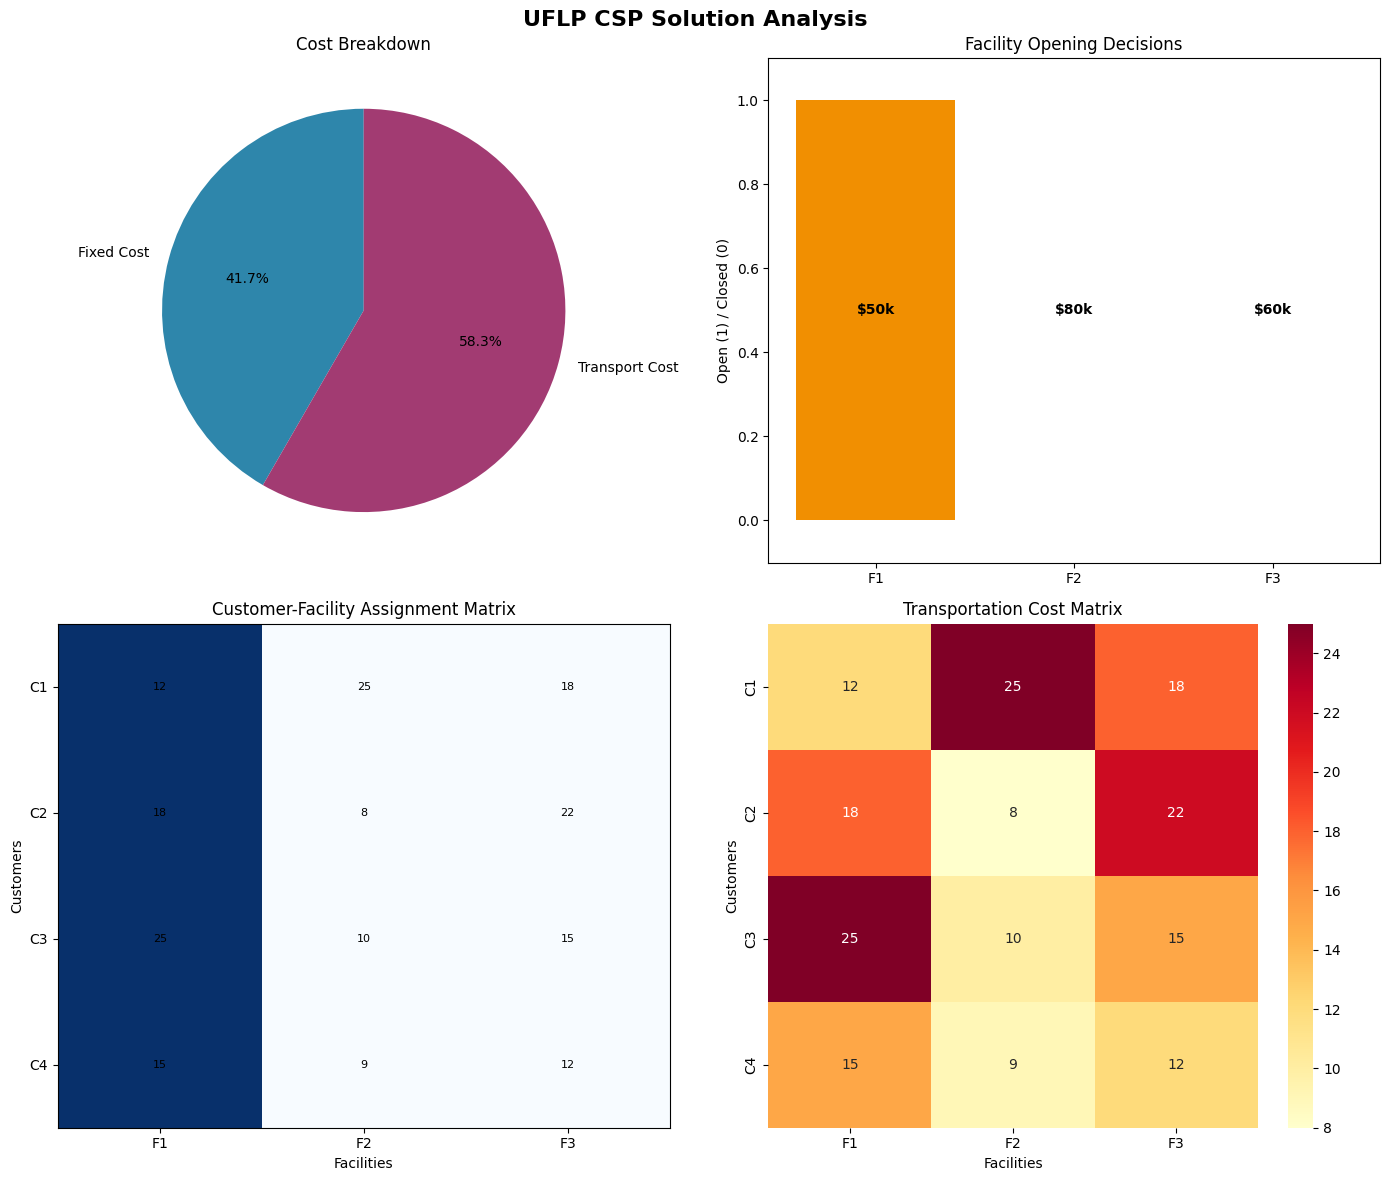


=== DETAILED ASSIGNMENT ANALYSIS ===
Customer -> Facility (Cost)
Customer 1 -> Facility 1 (Cost: 12)
Customer 2 -> Facility 1 (Cost: 18)
Customer 3 -> Facility 1 (Cost: 25)
Customer 4 -> Facility 1 (Cost: 15)


In [6]:
# Simple visualization without complex variable scoping
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('UFLP CSP Solution Analysis', fontsize=16, fontweight='bold')

# 1. Cost breakdown
ax1 = axes[0, 0]
costs = [solution.fixed_cost, solution.transport_cost]
labels = ['Fixed Cost', 'Transport Cost']
colors = ['#2E86AB', '#A23B72']
ax1.pie(costs, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Cost Breakdown')

# 2. Facility opening decisions
ax2 = axes[0, 1]
facility_numbers = [f'F{j+1}' for j in range(instance.n_facilities)]
open_values = [1 if solution.facilities_open[j] else 0 for j in range(instance.n_facilities)]
colors_fac = ['#F18F01' if solution.facilities_open[j] else '#C73E1D' for j in range(instance.n_facilities)]
bars = ax2.bar(facility_numbers, open_values, color=colors_fac)
ax2.set_title('Facility Opening Decisions')
ax2.set_ylabel('Open (1) / Closed (0)')
ax2.set_ylim(-0.1, 1.1)

# Add facility fixed costs as text
for i, bar in enumerate(bars):
    ax2.text(bar.get_x() + bar.get_width()/2, 0.5, f'${instance.fixed_costs[i]}k', 
            ha='center', va='center', fontweight='bold')

# 3. Customer-facility assignment matrix
ax3 = axes[1, 0]
assignment_matrix = np.zeros((instance.n_customers, instance.n_facilities))
for i, facility in enumerate(solution.assignments):
    assignment_matrix[i, facility] = 1

im = ax3.imshow(assignment_matrix, cmap='Blues', aspect='auto')
ax3.set_title('Customer-Facility Assignment Matrix')
ax3.set_xlabel('Facilities')
ax3.set_ylabel('Customers')
ax3.set_xticks(range(instance.n_facilities))
ax3.set_xticklabels([f'F{j+1}' for j in range(instance.n_facilities)])
ax3.set_yticks(range(instance.n_customers))
ax3.set_yticklabels([f'C{i+1}' for i in range(instance.n_customers)])

# Add assignment values
for i in range(instance.n_customers):
    for j in range(instance.n_facilities):
        text = ax3.text(j, i, f'{instance.transport_costs[i,j]}',
                       ha="center", va="center", color="black", fontsize=8)

# 4. Transportation cost heatmap
ax4 = axes[1, 1]
sns.heatmap(instance.transport_costs, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=[f'F{j+1}' for j in range(instance.n_facilities)],
            yticklabels=[f'C{i+1}' for i in range(instance.n_customers)],
            ax=ax4)
ax4.set_title('Transportation Cost Matrix')
ax4.set_xlabel('Facilities')
ax4.set_ylabel('Customers')

plt.tight_layout()
plt.show()

# Print detailed assignment information
print("\n=== DETAILED ASSIGNMENT ANALYSIS ===")
print("Customer -> Facility (Cost)")
for i, facility in enumerate(solution.assignments):
    cost = instance.transport_costs[i, facility]
    print(f"Customer {i+1} -> Facility {facility+1} (Cost: {cost})")

=== SENSITIVITY ANALYSIS ===

1. Fixed Cost Sensitivity:
Starting CSP solver for UFLP...
Search completed. Nodes explored: 13
  0.8x: Total Cost = 110.0, Facilities Open = 1
Starting CSP solver for UFLP...
Search completed. Nodes explored: 13
  0.9x: Total Cost = 115.0, Facilities Open = 1
Starting CSP solver for UFLP...
Search completed. Nodes explored: 13
  1.0x: Total Cost = 120.0, Facilities Open = 1
Starting CSP solver for UFLP...
Search completed. Nodes explored: 11
  1.1x: Total Cost = 125.0, Facilities Open = 1
Starting CSP solver for UFLP...
Search completed. Nodes explored: 11
  1.2x: Total Cost = 130.0, Facilities Open = 1

2. Transport Cost Sensitivity:
Starting CSP solver for UFLP...
Search completed. Nodes explored: 11
  0.8x: Total Cost = 106.0, Facilities Open = 1
Starting CSP solver for UFLP...
Search completed. Nodes explored: 11
  0.9x: Total Cost = 113.0, Facilities Open = 1
Starting CSP solver for UFLP...
Search completed. Nodes explored: 13
  1.0x: Total Cost = 12

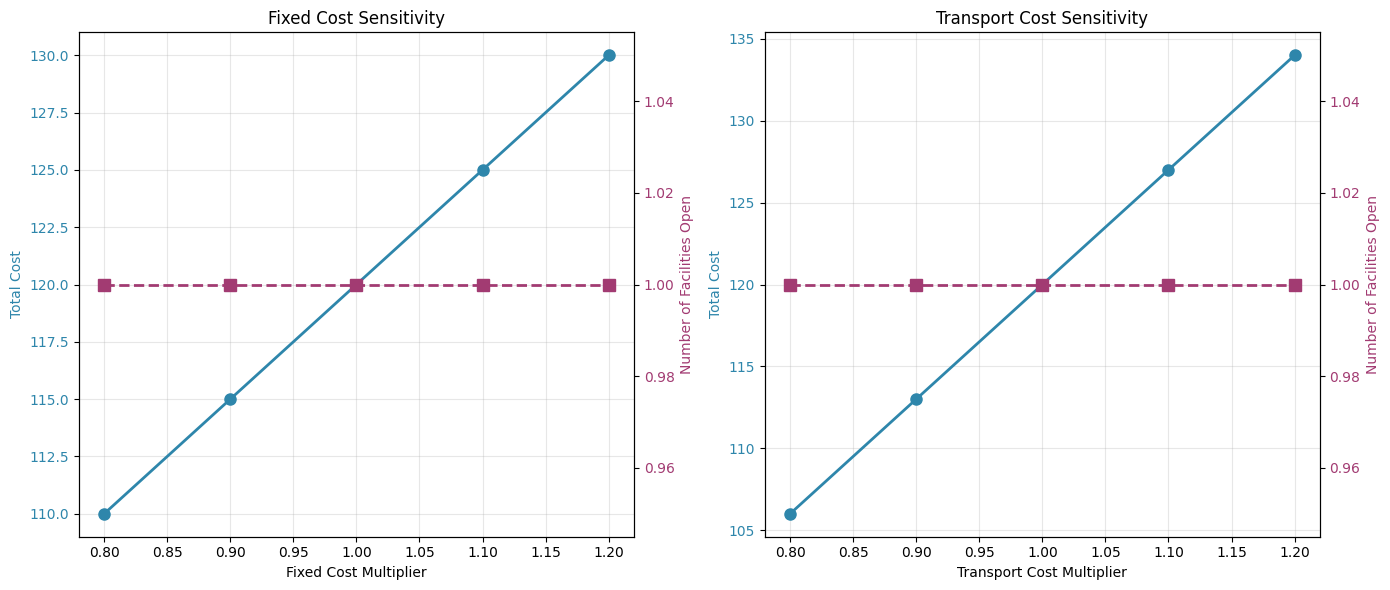

In [7]:
def sensitivity_analysis(instance):
    """Perform sensitivity analysis on key parameters
    
    Args:
        instance: Base UFLP instance
    """
    print("=== SENSITIVITY ANALYSIS ===")
    
    # 1. Fixed cost sensitivity
    print("\n1. Fixed Cost Sensitivity:")
    fixed_cost_multipliers = [0.8, 0.9, 1.0, 1.1, 1.2]
    fixed_cost_results = []
    
    for multiplier in fixed_cost_multipliers:
        modified_instance = UFLPInstance(
            n_facilities=instance.n_facilities,
            n_customers=instance.n_customers,
            fixed_costs=[cost * multiplier for cost in instance.fixed_costs],
            transport_costs=instance.transport_costs.copy()
        )
        
        solver = UFLPCSPSolver(modified_instance)
        result = solver.solve()
        
        fixed_cost_results.append({
            'multiplier': multiplier,
            'total_cost': result.total_cost,
            'facilities_open': sum(result.facilities_open),
            'fixed_cost': result.fixed_cost
        })
        
        print(f"  {multiplier:.1f}x: Total Cost = {result.total_cost}, Facilities Open = {sum(result.facilities_open)}")
    
    # 2. Transport cost sensitivity
    print("\n2. Transport Cost Sensitivity:")
    transport_multipliers = [0.8, 0.9, 1.0, 1.1, 1.2]
    transport_results = []
    
    for multiplier in transport_multipliers:
        modified_instance = UFLPInstance(
            n_facilities=instance.n_facilities,
            n_customers=instance.n_customers,
            fixed_costs=instance.fixed_costs.copy(),
            transport_costs=instance.transport_costs * multiplier
        )
        
        solver = UFLPCSPSolver(modified_instance)
        result = solver.solve()
        
        transport_results.append({
            'multiplier': multiplier,
            'total_cost': result.total_cost,
            'facilities_open': sum(result.facilities_open),
            'transport_cost': result.transport_cost
        })
        
        print(f"  {multiplier:.1f}x: Total Cost = {result.total_cost}, Facilities Open = {sum(result.facilities_open)}")
    
    # Create sensitivity plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Fixed cost sensitivity plot
    multipliers1 = [r['multiplier'] for r in fixed_cost_results]
    total_costs1 = [r['total_cost'] for r in fixed_cost_results]
    facilities_open1 = [r['facilities_open'] for r in fixed_cost_results]
    
    ax1.plot(multipliers1, total_costs1, 'o-', linewidth=2, markersize=8, color='#2E86AB')
    ax1.set_xlabel('Fixed Cost Multiplier')
    ax1.set_ylabel('Total Cost', color='#2E86AB')
    ax1.tick_params(axis='y', labelcolor='#2E86AB')
    ax1.set_title('Fixed Cost Sensitivity')
    ax1.grid(True, alpha=0.3)
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(multipliers1, facilities_open1, 's--', linewidth=2, markersize=8, color='#A23B72')
    ax1_twin.set_ylabel('Number of Facilities Open', color='#A23B72')
    ax1_twin.tick_params(axis='y', labelcolor='#A23B72')
    
    # Transport cost sensitivity plot
    multipliers2 = [r['multiplier'] for r in transport_results]
    total_costs2 = [r['total_cost'] for r in transport_results]
    facilities_open2 = [r['facilities_open'] for r in transport_results]
    
    ax2.plot(multipliers2, total_costs2, 'o-', linewidth=2, markersize=8, color='#2E86AB')
    ax2.set_xlabel('Transport Cost Multiplier')
    ax2.set_ylabel('Total Cost', color='#2E86AB')
    ax2.tick_params(axis='y', labelcolor='#2E86AB')
    ax2.set_title('Transport Cost Sensitivity')
    ax2.grid(True, alpha=0.3)
    
    ax2_twin = ax2.twinx()
    ax2_twin.plot(multipliers2, facilities_open2, 's--', linewidth=2, markersize=8, color='#A23B72')
    ax2_twin.set_ylabel('Number of Facilities Open', color='#A23B72')
    ax2_twin.tick_params(axis='y', labelcolor='#A23B72')
    
    plt.tight_layout()
    plt.show()

# Perform sensitivity analysis
sensitivity_analysis(instance)

=== CSP vs GREEDY COMPARISON ===

Method       Total Cost   Fixed      Transport    Facilities  
-----------------------------------------------------------------
CSP Optimal  120.0        50.0       70.0         1           
Greedy       229.0        190.0      39.0         3           

Optimality Gap: 90.83% (Greedy is 90.83% worse than optimal)


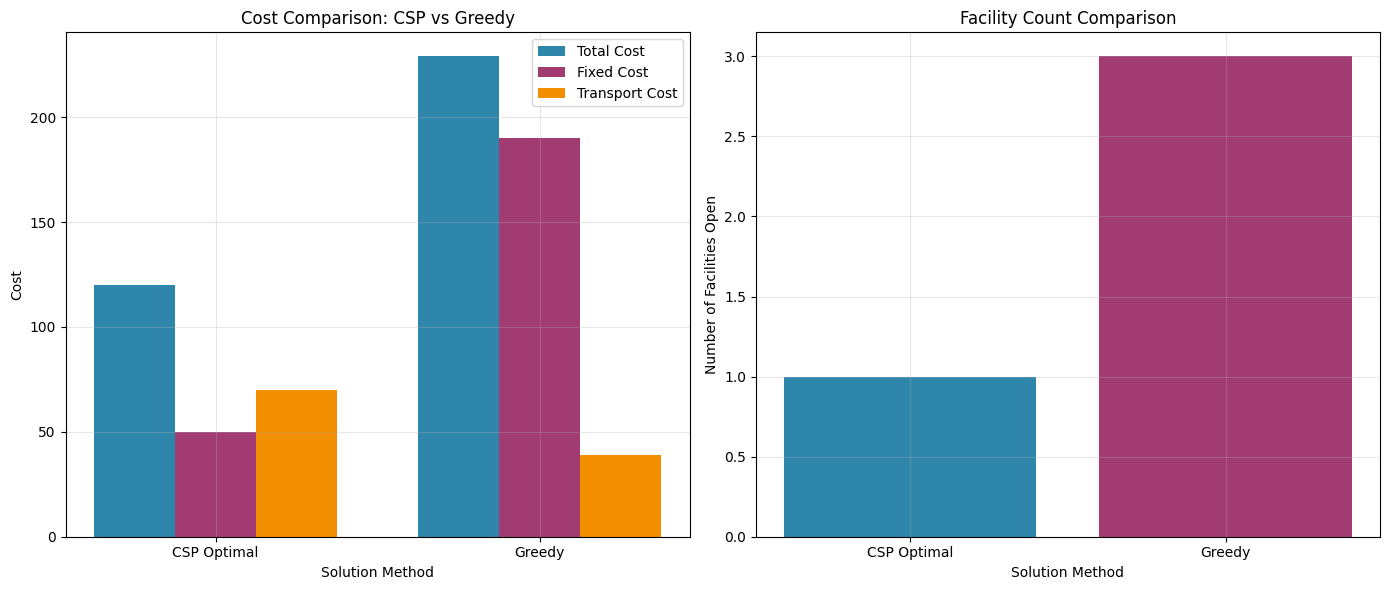

In [8]:
def compare_with_greedy(instance, optimal_solution):
    """Compare CSP optimal solution with greedy heuristic
    
    Args:
        instance: UFLP instance
        optimal_solution: Optimal solution from CSP
    """
    def greedy_solution():
        """Simple greedy heuristic: open facility with minimum average cost per customer"""
        # Calculate average transport cost per facility
        avg_costs = []
        for j in range(instance.n_facilities):
            avg_transport = np.mean(instance.transport_costs[:, j])
            total_avg_cost = instance.fixed_costs[j] + avg_transport * instance.n_customers
            avg_costs.append((j, total_avg_cost))
        
        # Sort facilities by average cost
        facility_order = np.argsort([cost for _, cost in avg_costs])
        
        # Greedily open facilities
        facilities_open = [False] * instance.n_facilities
        assignments = [-1] * instance.n_customers
        
        for j in facility_order:
            # Check if opening this facility improves any assignment
            improved = False
            for i in range(instance.n_customers):
                current_cost = (instance.transport_costs[i, assignments[i]] 
                               if assignments[i] >= 0 else float('inf'))
                new_cost = instance.transport_costs[i, j]
                if new_cost < current_cost:
                    assignments[i] = j
                    improved = True
            
            if improved:
                facilities_open[j] = True
        
        # Ensure all customers are assigned
        for i in range(instance.n_customers):
            if assignments[i] == -1:
                min_cost = float('inf')
                best_facility = -1
                for j in range(instance.n_facilities):
                    if facilities_open[j]:
                        cost = instance.transport_costs[i, j]
                        if cost < min_cost:
                            min_cost = cost
                            best_facility = j
                
                if best_facility >= 0:
                    assignments[i] = best_facility
                else:
                    # Open cheapest facility for this customer
                    min_fixed = float('inf')
                    best_facility = -1
                    for j in range(instance.n_facilities):
                        total_cost = instance.fixed_costs[j] + instance.transport_costs[i, j]
                        if total_cost < min_fixed:
                            min_fixed = total_cost
                            best_facility = j
                    
                    facilities_open[best_facility] = True
                    assignments[i] = best_facility
        
        # Calculate total cost
        fixed_cost = sum(instance.fixed_costs[j] 
                        for j in range(instance.n_facilities) if facilities_open[j])
        transport_cost = sum(instance.transport_costs[i, assignments[i]] 
                           for i in range(instance.n_customers))
        total_cost = fixed_cost + transport_cost
        
        return UFLPSolution(
            facilities_open=facilities_open,
            assignments=assignments,
            total_cost=total_cost,
            fixed_cost=fixed_cost,
            transport_cost=transport_cost,
            feasible=True
        )
    
    # Get greedy solution
    greedy = greedy_solution()
    
    print("=== CSP vs GREEDY COMPARISON ===")
    
    solutions = [
        ("CSP Optimal", optimal_solution),
        ("Greedy", greedy)
    ]
    
    print(f"\n{'Method':<12} {'Total Cost':<12} {'Fixed':<10} {'Transport':<12} {'Facilities':<12}")
    print("-" * 65)
    
    for name, sol in solutions:
        print(f"{name:<12} {sol.total_cost:<12.1f} {sol.fixed_cost:<10.1f} "
              f"{sol.transport_cost:<12.1f} {sum(sol.facilities_open):<12}")
    
    # Calculate optimality gap
    gap = ((greedy.total_cost - optimal_solution.total_cost) / optimal_solution.total_cost) * 100
    print(f"\nOptimality Gap: {gap:.2f}% (Greedy is {gap:.2f}% worse than optimal)")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Cost comparison
    methods = [name for name, _ in solutions]
    total_costs = [sol.total_cost for _, sol in solutions]
    fixed_costs = [sol.fixed_cost for _, sol in solutions]
    transport_costs = [sol.transport_cost for _, sol in solutions]
    
    x = np.arange(len(methods))
    width = 0.25
    
    ax1.bar(x - width, total_costs, width, label='Total Cost', color='#2E86AB')
    ax1.bar(x, fixed_costs, width, label='Fixed Cost', color='#A23B72')
    ax1.bar(x + width, transport_costs, width, label='Transport Cost', color='#F18F01')
    
    ax1.set_xlabel('Solution Method')
    ax1.set_ylabel('Cost')
    ax1.set_title('Cost Comparison: CSP vs Greedy')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Facility count comparison
    facility_counts = [sum(sol.facilities_open) for _, sol in solutions]
    colors_fac = ['#2E86AB', '#A23B72']
    
    ax2.bar(methods, facility_counts, color=colors_fac)
    ax2.set_xlabel('Solution Method')
    ax2.set_ylabel('Number of Facilities Open')
    ax2.set_title('Facility Count Comparison')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Compare CSP with greedy heuristic
compare_with_greedy(instance, solution)

### Why this Tier exists vs earlier Tiers
This Tier 1 provides the mathematical foundation with **exact optimality guarantees** through constraint satisfaction programming. Unlike heuristic approaches that may find good solutions quickly, the CSP formulation with branch-and-bound search guarantees finding the provably optimal solution.

**Advantages vs heuristic methods:**
- **Optimality guarantee**: Finds the provably best solution
- **Systematic exploration**: Exhaustive search with intelligent pruning
- **Constraint propagation**: Reduces search space efficiently
- **Lower bound calculations**: Enables effective branch-and-bound pruning

**Disadvantages vs heuristic methods:**
- **Computational complexity**: Exponential worst-case time complexity
- **Scalability limits**: Becomes impractical for large instances
- Memory requirements**: Needs to store search tree and bounds

**When to use this Tier:**
- Small to medium-sized instances where optimality is critical
- Benchmarking heuristic algorithms on known optimal solutions
- Strategic decisions where solution quality outweighs computation time
- Academic and research settings requiring provable optimality

### Pros / Cons Summary
**Pros:**
✓ Guaranteed optimal solution
✓ Systematic and reproducible methodology
✓ Strong theoretical foundation
✓ Effective constraint propagation reduces search space
✓ Provides lower bounds for problem complexity analysis

**Cons:**
✗ Exponential computational complexity
✗ Limited scalability for large instances
✗ Higher implementation complexity
✗ May be impractical for real-time decisions

This mathematical CSP approach establishes the theoretical baseline against which all other solution methods (Tiers 2-9) will be compared.